# 02 — Segment cells and assign transcripts

Runs Cellpose on a centre crop of the OME-TIFF image, then assigns each Xenium transcript
to a cell based on whether its spatial coordinate falls inside a segmented mask.

**Inputs**
- `data/morphology_focus_0000.ome.tif` — full morphology image
- `data/transcripts.parquet` — Xenium transcript table with `x_location`, `y_location`, `feature_name`

**Outputs**
- `data/masks_center.npy` — Cellpose segmentation mask (512 × 512)
- `data/cell_expression_aligned.csv` — cells × genes count matrix
- `outputs/figures/center_crop.png`
- `outputs/figures/center_crop_normalized.png`
- `outputs/figures/overlay_center.png`
- `outputs/figures/assignment_qc.png`

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile as tiff
from pathlib import Path
import zarr
from cellpose import models

## Config

In [2]:
DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MORPHOLOGY_DIR = DATA_DIR / "morphology_focus"
TRANSCRIPTS_ZARR_PATH = DATA_DIR / "transcripts.zarr"
SHARED_GENES_PATH = OUTPUT_DIR / "shared_genes.txt"

MASK_PATH = DATA_DIR / "masks_center.npy"
CELL_EXPR_PATH = OUTPUT_DIR / "cell_expression_aligned.csv"
ASSIGNED_TRANSCRIPTS_PATH = OUTPUT_DIR / "assigned_transcripts_crop.csv"
CROP_SIZE = 512
CELL_DIAMETER = 30

GENE_COL = "feature_name"
X_COL = "x_location"
Y_COL = "y_location"

MICRONS_PER_PIXEL = 0.2125

## 1 · Load image and take centre crop

Using image: ../data/morphology_focus/morphology_focus_0000.ome.tif
Original image shape: (74945, 51265)
Crop shape: (512, 512)
Crop offsets: start_x=25376, start_y=37216
Pixel range: [36, 10406]


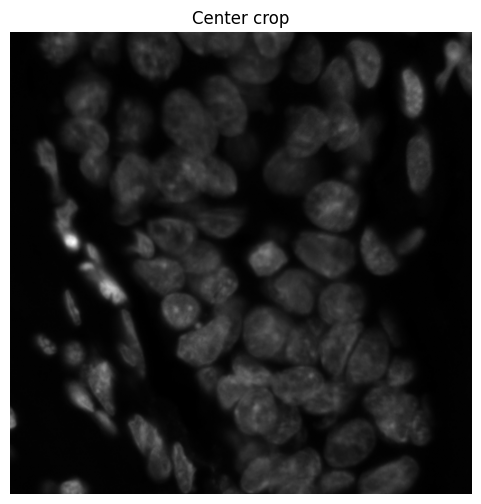

In [3]:
image_files = sorted(
    list(MORPHOLOGY_DIR.glob("*.ome.tif")) +
    list(MORPHOLOGY_DIR.glob("*.ome.tiff")) +
    list(MORPHOLOGY_DIR.glob("*.tif")) +
    list(MORPHOLOGY_DIR.glob("*.tiff"))
)

if len(image_files) == 0:
    raise FileNotFoundError(f"No TIFF images found in {MORPHOLOGY_DIR}")

IMAGE_PATH = image_files[0]
print(f"Using image: {IMAGE_PATH}")

with tiff.TiffFile(IMAGE_PATH) as tif:
    img = tif.pages[0].asarray()

print("Original image shape:", img.shape)

if img.ndim == 3:
    img = img[..., 0]

h, w = img.shape

start_y = h // 2 - CROP_SIZE // 2
start_x = w // 2 - CROP_SIZE // 2

img_crop = img[start_y:start_y + CROP_SIZE, start_x:start_x + CROP_SIZE]

print(f"Crop shape: {img_crop.shape}")
print(f"Crop offsets: start_x={start_x}, start_y={start_y}")
print(f"Pixel range: [{img_crop.min()}, {img_crop.max()}]")

plt.figure(figsize=(6, 6))
plt.imshow(img_crop, cmap="gray")
plt.title("Center crop")
plt.axis("off")
plt.savefig(FIGURES_DIR / "center_crop.png", bbox_inches="tight", dpi=200)
plt.show()

## 2 · Normalise crop for Cellpose

In [4]:
img_crop = img_crop.astype(np.float32)
pmin, pmax = img_crop.min(), img_crop.max()

if pmax <= pmin:
    raise ValueError(
        "Crop is blank (min == max). "
        "Try adjusting CROP_SIZE or start_x/start_y to a region with tissue."
    )

img_crop_norm = (img_crop - pmin) / (pmax - pmin)

plt.figure(figsize=(6, 6))
plt.imshow(img_crop_norm, cmap="gray")
plt.title("Normalised centre crop")
plt.axis("off")
plt.savefig(FIGURES_DIR / "center_crop_normalized.png", bbox_inches="tight", dpi=200)
plt.close()

## 3 · Run Cellpose

In [5]:
model = models.CellposeModel(gpu=True)

t0 = time.time()
masks, flows, styles = model.eval(
    img_crop_norm,
    diameter=CELL_DIAMETER,
    batch_size=8
)
print(f"Cellpose finished in {time.time() - t0:.1f}s  |  cells found: {int(masks.max())}")

np.save(MASK_PATH, masks)
print(f"Saved mask → {MASK_PATH}")

plt.figure(figsize=(6, 6))
plt.imshow(img_crop_norm, cmap="gray")
plt.contour(masks, levels=np.unique(masks)[1:], linewidths=0.3)
plt.title("Segmentation overlay")
plt.axis("off")
plt.savefig(FIGURES_DIR / "overlay_center.png", bbox_inches="tight", dpi=200)
plt.close()

/Users/mahsa/Projects/Computational-Genomics-Project/.venv/lib/python3.10/site-packages/cellpose/dynamics.py:524: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


Cellpose finished in 3.2s  |  cells found: 82
Saved mask → ../data/masks_center.npy


## 4 · Assign transcripts to cells

Transcripts are stored in full-image pixel coordinates. We subtract the crop offset so
coordinates line up with the 512×512 mask, then look up each transcript's cell ID.

In [6]:
z = zarr.open(TRANSCRIPTS_ZARR_PATH, mode="r")

print(z.tree())

def zarr_to_array(group, key):
    arr = group[key][:]
    if arr.dtype.kind in {"S", "O"}:
        arr = arr.astype(str)
    return arr

print("Transcript zarr keys:")
print(list(z.keys()))

/
 ├── codeword_category (19259, 8) bool
 ├── density
 │   └── gene
 │       ├── data (69889909,) uint16
 │       ├── indices (69889909,) uint16
 │       └── indptr (15084201,) uint32
 ├── gene_category (9475, 8) bool
 ├── grids
 │   ├── 0
 │   │   ├── 0,10
 │   │   │   ├── codeword_identity (23, 2) uint16
 │   │   │   ├── gene_identity (23, 1) uint16
 │   │   │   ├── gene_offset (9475, 4) uint32
 │   │   │   ├── id (23, 2) uint32
 │   │   │   ├── location (23, 3) float32
 │   │   │   ├── quality_score (23, 1) float32
 │   │   │   ├── status (23, 1) uint8
 │   │   │   ├── uuid (23, 2) uint32
 │   │   │   └── valid (23, 1) uint8
 │   │   ├── 0,11
 │   │   │   ├── codeword_identity (13, 2) uint16
 │   │   │   ├── gene_identity (13, 1) uint16
 │   │   │   ├── gene_offset (9475, 4) uint32
 │   │   │   ├── id (13, 2) uint32
 │   │   │   ├── location (13, 3) float32
 │   │   │   ├── quality_score (13, 1) float32
 │   │   │   ├── status (13, 1) uint8
 │   │   │   ├── uuid (13, 2) uint32
 │   

In [7]:
# Inspect likely transcript fields
for key in z.keys():
    try:
        obj = z[key]
        print(key, getattr(obj, "shape", None), getattr(obj, "dtype", None))
    except Exception as e:
        print(key, e)

codeword_category (19259, 8) bool
density None None
gene_category (9475, 8) bool
grids None None
metrics_density (796, 544, 4) float32


In [8]:
# Convert Xenium zarr transcripts into dataframe
import json

GENE_PANEL_PATH = DATA_DIR / "gene_panel.json"

with open(GENE_PANEL_PATH, "r") as f:
    gene_panel = json.load(f)

targets = gene_panel["payload"]["targets"]

# Map target index/codeword identity to gene name
id_to_gene = {}

for i, target in enumerate(targets):
    gene_name = None

    if (
        isinstance(target, dict)
        and "type" in target
        and isinstance(target["type"], dict)
        and "data" in target["type"]
        and isinstance(target["type"]["data"], dict)
        and "name" in target["type"]["data"]
    ):
        gene_name = target["type"]["data"]["name"]
    elif isinstance(target, dict) and "name" in target:
        gene_name = target["name"]

    if gene_name is not None:
        id_to_gene[i] = str(gene_name)

print(f"Mapped {len(id_to_gene):,} gene/codeword IDs to gene names.")

Mapped 8,456 gene/codeword IDs to gene names.


In [9]:
# Read transcript locations from zarr grids

rows = []
grid_root = z["grids"]

for grid_key in grid_root.keys():
    grid_group = grid_root[grid_key]

    for tile_key in grid_group.keys():
        tile = grid_group[tile_key]

        if "location" not in tile:
            continue

        loc = tile["location"][:]  # usually columns: x, y, z or x, y, quality-like value

        if "gene_identity" in tile:
            gene_ids = tile["gene_identity"][:]

            # gene_identity may be shape (n,) or (n, 2)
            if gene_ids.ndim == 2:
                gene_ids = gene_ids[:, 0]

        elif "codeword_identity" in tile:
            gene_ids = tile["codeword_identity"][:]

            if gene_ids.ndim == 2:
                gene_ids = gene_ids[:, 0]

        else:
            continue

        gene_names = [id_to_gene.get(int(g), None) for g in gene_ids]

        df = pd.DataFrame({
            X_COL: loc[:, 0],
            Y_COL: loc[:, 1],
            GENE_COL: gene_names,
        })

        rows.append(df)

transcripts = pd.concat(rows, ignore_index=True)

# Drop rows where gene name could not be mapped
transcripts = transcripts.dropna(subset=[GENE_COL]).copy()

print("Transcript dataframe:")
print(transcripts.shape)
display(transcripts.head())

print("Transcript columns:", transcripts.columns.tolist())
print("Transcript x range:", transcripts[X_COL].min(), transcripts[X_COL].max())
print("Transcript y range:", transcripts[Y_COL].min(), transcripts[Y_COL].max())
print("Unique genes:", transcripts[GENE_COL].nunique())

Transcript dataframe:
(386985335, 3)


,x_location,y_location,feature_name
0,71.12500,2615.046875,CUZD1
1,200.21875,2510.718750,DMXL2
2,140.06250,2702.296875,DOT1L
3,70.43750,2519.593750,EGR3
4,137.21875,2734.031250,HDAC2


Transcript columns: ['x_location', 'y_location', 'feature_name']
Transcript x range: 18.140625 10880.016
Transcript y range: 3.109375 15916.906
Unique genes: 8455


## 5 · Build cell × gene expression matrix

In [10]:
# Assign transcripts to Cellpose cells

start_x_um = start_x * MICRONS_PER_PIXEL
start_y_um = start_y * MICRONS_PER_PIXEL
end_x_um = (start_x + CROP_SIZE) * MICRONS_PER_PIXEL
end_y_um = (start_y + CROP_SIZE) * MICRONS_PER_PIXEL

print(f"Crop in microns: x=[{start_x_um:.2f}, {end_x_um:.2f}], y=[{start_y_um:.2f}, {end_y_um:.2f}]")
print(f"Transcript x range: [{transcripts[X_COL].min():.2f}, {transcripts[X_COL].max():.2f}]")
print(f"Transcript y range: [{transcripts[Y_COL].min():.2f}, {transcripts[Y_COL].max():.2f}]")

in_crop = (
    (transcripts[X_COL] >= start_x_um) & (transcripts[X_COL] < end_x_um) &
    (transcripts[Y_COL] >= start_y_um) & (transcripts[Y_COL] < end_y_um)
)

tx = transcripts.loc[in_crop].copy()

print(f"Transcripts in crop: {len(tx):,} / {len(transcripts):,}")

tx["x_local"] = ((tx[X_COL] - start_x_um) / MICRONS_PER_PIXEL).astype(int).clip(0, CROP_SIZE - 1)
tx["y_local"] = ((tx[Y_COL] - start_y_um) / MICRONS_PER_PIXEL).astype(int).clip(0, CROP_SIZE - 1)

tx["cell_id"] = masks[tx["y_local"], tx["x_local"]]

assigned = tx[tx["cell_id"] > 0].copy()
unassigned = tx[tx["cell_id"] == 0].copy()

print(f"Assigned: {len(assigned):,}")
print(f"Unassigned: {len(unassigned):,}")

Crop in microns: x=[5392.40, 5501.20], y=[7908.40, 8017.20]
Transcript x range: [18.14, 10880.02]
Transcript y range: [3.11, 15916.91]
Transcripts in crop: 116,364 / 386,985,335
Assigned: 78,588
Unassigned: 37,776


In [11]:
# Build cell × gene expression matrix


with open(SHARED_GENES_PATH) as f:
    shared_genes = [line.strip() for line in f if line.strip()]

print(f"Shared genes loaded: {len(shared_genes):,}")

assigned_shared = assigned[assigned[GENE_COL].isin(shared_genes)].copy()

print(f"Assigned transcripts before gene filtering: {len(assigned):,}")
print(f"Assigned transcripts after gene filtering:  {len(assigned_shared):,}")

cell_expr = (
    assigned_shared
    .groupby(["cell_id", GENE_COL])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=shared_genes, fill_value=0)
)

cell_expr.index = [f"cell_{int(i)}" for i in cell_expr.index]

print("Cell expression matrix:", cell_expr.shape, "(cells × genes)")
display(cell_expr.iloc[:5, :5])

cell_expr.to_csv(CELL_EXPR_PATH)
assigned_shared.to_csv(ASSIGNED_TRANSCRIPTS_PATH, index=False)

print(f"Saved cell expression matrix → {CELL_EXPR_PATH}")
print(f"Saved assigned transcripts → {ASSIGNED_TRANSCRIPTS_PATH}")

Shared genes loaded: 5,054
Assigned transcripts before gene filtering: 78,588
Assigned transcripts after gene filtering:  74,005
Cell expression matrix: (82, 5054) (cells × genes)


feature_name,A2ML1,AAMP,AAR2,AARSD1,ABAT
cell_1,0,0,0,0,0
cell_2,0,0,0,0,0
cell_3,3,0,0,0,0
cell_4,0,0,0,0,0
cell_5,0,0,0,0,0


Saved cell expression matrix → ../outputs/cell_expression_aligned.csv
Saved assigned transcripts → ../outputs/assigned_transcripts_crop.csv


In [12]:
# Save assigned transcript table

assigned_shared.to_csv(ASSIGNED_TRANSCRIPTS_PATH, index=False)

print(f"Saved assigned transcripts → {ASSIGNED_TRANSCRIPTS_PATH}")
print("Assigned transcript columns:")
print(assigned_shared.columns.tolist())

Saved assigned transcripts → ../outputs/assigned_transcripts_crop.csv
Assigned transcript columns:
['x_location', 'y_location', 'feature_name', 'x_local', 'y_local', 'cell_id']


## 6 · QC plot

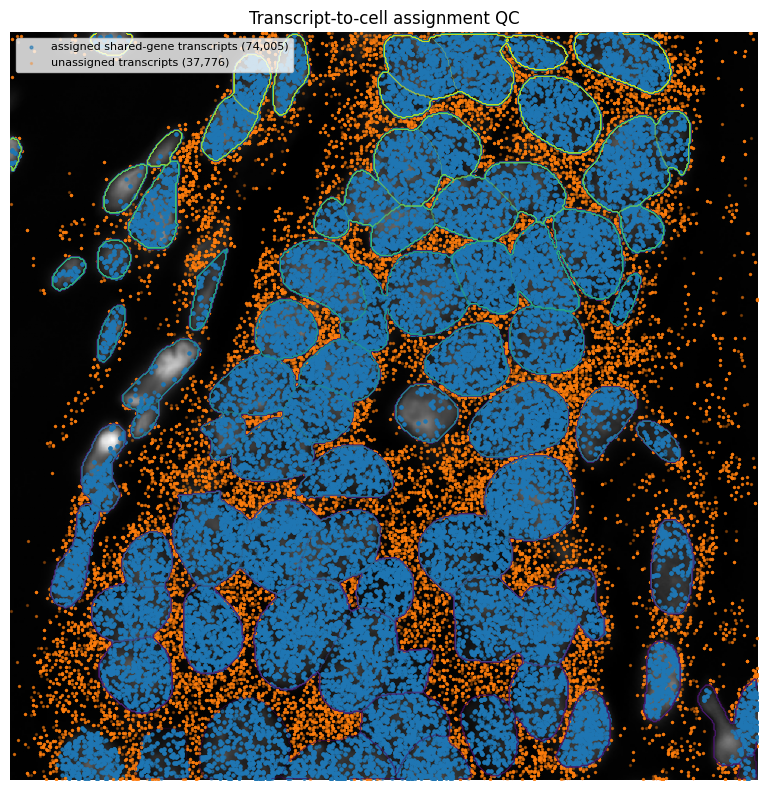

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(img_crop_norm, cmap="gray")

levels = np.unique(masks)
levels = levels[levels > 0]

if len(levels) > 0:
    ax.contour(masks, levels=levels, linewidths=0.2)

if len(assigned_shared) > 0:
    ax.scatter(
        assigned_shared["x_local"],
        assigned_shared["y_local"],
        s=4,
        alpha=0.6,
        label=f"assigned shared-gene transcripts ({len(assigned_shared):,})"
    )

if len(unassigned) > 0:
    ax.scatter(
        unassigned["x_local"],
        unassigned["y_local"],
        s=2,
        alpha=0.3,
        label=f"unassigned transcripts ({len(unassigned):,})"
    )

ax.invert_yaxis()
ax.legend(fontsize=8)
ax.set_title("Transcript-to-cell assignment QC")
ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "assignment_qc.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
# Notebook 02 sanity checks

print("Notebook 02 sanity check")
print("------------------------")
print(f"Cellpose cells found:              {int(masks.max()):,}")
print(f"Transcripts in crop:               {len(tx):,}")
print(f"Assigned transcripts:              {len(assigned):,}")
print(f"Assigned shared-gene transcripts:  {len(assigned_shared):,}")
print(f"Unassigned transcripts:            {len(unassigned):,}")
print(f"Shared genes:                      {len(shared_genes):,}")
print(f"Cell expression shape:             {cell_expr.shape}")

assert cell_expr.shape[1] == len(shared_genes)
assert list(cell_expr.columns) == shared_genes

print("\nNotebook 02 completed successfully.")

Notebook 02 sanity check
------------------------
Cellpose cells found:              82
Transcripts in crop:               116,364
Assigned transcripts:              78,588
Assigned shared-gene transcripts:  74,005
Unassigned transcripts:            37,776
Shared genes:                      5,054
Cell expression shape:             (82, 5054)

Notebook 02 completed successfully.
